# Đồ án 05 – Giọng điệu văn bản báo cáo và phản ứng thị trường (Mỹ + Việt Nam)
Notebook chạy **từ dữ liệu đã xử lý** (`data/<thị trường>/processed/`). Muốn tải lại từ đầu: `python run_all.py --market both`.

**Câu hỏi:** giọng điệu (tone) của 10-K / Thông điệp của ban lãnh đạo có tác động tích cực hay tiêu cực lên CAR[T, T+3] không – văn bản có mang thông tin cho thị trường không?

In [1]:
import sys, os, pathlib, pandas as pd
from IPython.display import display, Image, Markdown
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / 'src')); os.chdir(ROOT)
from analysis import a01_tone, a02_event, a03_regress, a04_figures, a06_summary
MARKETS = [m for m in ['us', 'vn'] if (ROOT / 'data' / m / 'processed' / 'docs.csv').exists()]
MARKETS

['us', 'vn']

## 1. Chạy lại phần phân tích (tone → sự kiện → hồi quy → hình)

In [2]:
for m in MARKETS:
    txt = ROOT / 'data' / m / 'interim' / 'text'
    # a01 cần văn bản đã trích (data/<mkt>/interim – không có trong git). Clone mới chưa chạy u02/v03 thì bỏ qua a01
    # và dùng tone_panel.csv đã commit trong data/<mkt>/processed.
    steps = ([a01_tone] if txt.exists() and any(txt.iterdir()) else []) + [a02_event, a03_regress, a04_figures, a06_summary]
    print(m, '→', [s.__name__.split('.')[-1] for s in steps])
    for step in steps:
        step.main(m)

us → ['a01_tone', 'a02_event', 'a03_regress', 'a04_figures', 'a06_summary']


Tone us:   0%|          | 0/500 [00:00<?, ?it/s]

Tone us:   0%|          | 2/500 [00:00<00:42, 11.71it/s]

Tone us:   1%|          | 4/500 [00:00<00:40, 12.16it/s]

Tone us:   1%|          | 6/500 [00:00<00:46, 10.52it/s]

...

Tone vn: 100%|██████████| 617/617 [00:07<00:00, 83.87it/s]

               count    mean     std     min     25%     50%     75%     max
fin_neg        617.0  0.0053  0.0047  0.0000  0.0015  0.0042  0.0076  0.0210
fin_pos        617.0  0.0306  0.0110  0.0066  0.0232  0.0298  0.0371  0.0602
fin_unc        617.0  0.0026  0.0024  0.0000  0.0009  0.0021  0.0038  0.0109
fin_lit        617.0  0.0000  0.0001  0.0000  0.0000  0.0000  0.0000  0.0008
fin_net        617.0  0.7090  0.2453  0.0000  0.5652  0.7576  0.9111  1.0000
gen_neg        617.0  0.0202  0.0070  0.0056  0.0155  0.0199  0.0247  0.0384
gen_pos        617.0  0.0538  0.0126  0.0251  0.0454  0.0534  0.0620  0.0841
gen_unc        617.0  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000
gen_lit        617.0  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000
gen_net        617.0  0.4473  0.1768  0.0000  0.3333  0.4468  0.5663  0.8292
fin_neg_tfidf  617.0  1.1751  1.2249  0.0000  0.2277  0.8256  1.6625  5.7250
gen_neg_tfidf  617.0  2.6899  1.9067  0.0120  1.3585  2.2807  3.5721  9.4042

517 sự kiện
                    window   N  mean_pct  median_pct       t    p_t  p_wilcoxon  pct_positive  p_sign   t_BMP
                 CAR[0,3] 514   -0.3036     -0.2423 -1.4184 0.1567      0.0876       46.4981  0.1226 -0.9931
 CAR market-adjusted[0,3] 514   -0.1267     -0.3428 -0.5954 0.5519      0.3094       46.6926  0.1454     NaN
                 CAR[0,1] 516   -0.0638     -0.1911 -0.4430 0.6580      0.1282       45.5426  0.0475 -0.4256
 CAR market-adjusted[0,1] 516    0.0219     -0.2222  0.1564 0.8758      0.2775       45.7364  0.0583     NaN
                CAR[-1,1] 514   -0.0391     -0.1972 -0.2272 0.8203      0.4043       46.3035  0.1026 -0.2393
CAR market-adjusted[-1,1] 514    0.0448     -0.0748  0.2752 0.7833      0.7480       48.2490  0.4534     NaN
                 CAR[0,5] 514   -0.7016     -0.6974 -2.7382 0.0064      0.0012       44.5525  0.0152 -2.0732
 CAR market-adjusted[0,5] 514   -0.5182     -0.5401 -2.0102 0.0449      0.0124       45.1362  0.0306     NaN
      

                            M1 nền         M2 fin_neg         M3 gen_neg         M4 đối đầu         M5 net+unc          M6 tf-idf
Intercept          0.0699 (0.0509)    0.0739 (0.0506)    0.0679 (0.0504)    0.0739 (0.0499)    0.0703 (0.0501)    0.0627 (0.0495)
log_tradeval     -0.0043* (0.0024)  -0.0044* (0.0024)  -0.0043* (0.0024)  -0.0044* (0.0024)  -0.0044* (0.0024)  -0.0044* (0.0024)
pre_ret           -0.0308 (0.0206)   -0.0320 (0.0205)   -0.0310 (0.0206)   -0.0320 (0.0205)   -0.0325 (0.0205)   -0.0321 (0.0203)
log_len            0.0000 (0.0040)   -0.0003 (0.0040)    0.0003 (0.0041)   -0.0003 (0.0040)    0.0001 (0.0039)    0.0013 (0.0042)
vn30               0.0020 (0.0056)    0.0019 (0.0055)    0.0023 (0.0056)    0.0019 (0.0056)    0.0010 (0.0056)    0.0018 (0.0054)
beta               0.0024 (0.0064)    0.0028 (0.0064)    0.0026 (0.0065)    0.0028 (0.0065)    0.0035 (0.0064)    0.0025 (0.0064)
N                              514                514                514                51

                                         buoc  so_van_ban
                              Mã VN30 + VN100         100
    Mã–năm có BCTN PDF trên CafeF (2016–2025)         813
     Tìm được Thông điệp HĐQT (ok + too_long)         617
               không tìm thấy thư (not_found)         195
       thư quá ngắn < 250 âm tiết (too_short)           0
     Có ngày sự kiện T=0 (PDF ModDate hợp lệ)         548
Có CAR (đủ dữ liệu giá, ≥ 80 phiên ước lượng)         517
                                  Có CAR[0,3]         514
           Vào hồi quy M2 (đủ biến kiểm soát)         514


## Kết quả: Mỹ – 10-K

**Mục tiêu 1 – thống kê tone**

,count,mean,std,min,25%,50%,75%,max
fin_neg,500.0,0.0190,0.0049,0.0083,0.0158,0.0192,0.0224,0.0322
fin_pos,500.0,0.0059,0.0017,0.0028,0.0048,0.0056,0.0067,0.0111
fin_unc,500.0,0.0161,0.0034,0.0084,0.0138,0.0157,0.0184,0.0239
fin_lit,500.0,0.0130,0.0043,0.0061,0.0098,0.0120,0.0158,0.0245
fin_net,500.0,-0.5194,0.1379,-0.7671,-0.6125,-0.5431,-0.4441,-0.1030
gen_neg,500.0,0.0276,0.0038,0.0173,0.0254,0.0275,0.0303,0.0353
gen_pos,500.0,0.0611,0.0070,0.0483,0.0559,0.0607,0.0658,0.0798
gen_unc,500.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
gen_lit,500.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
gen_net,500.0,0.3762,0.0785,0.2140,0.3219,0.3714,0.4178,0.6058


**Mục tiêu 2 – từ điển tổng quát gán sai**

```
Số văn bản: 500
Tỷ lệ 'nhiễu' của từ điển tổng quát (tần suất từ tiêu cực tổng quát không nằm trong danh sách tiêu cực tài chính): 73.9%

Tương quan:
         fin_neg  gen_neg  fin_net  gen_net
fin_neg    1.000    0.570   -0.644   -0.461
gen_neg    0.570    1.000   -0.387   -0.787
fin_net   -0.644   -0.387    1.000    0.332
gen_net   -0.461   -0.787    0.332    1.000

```

,word,freq,in_fin_negative,share_pct,nghia_trong_tai_chinh
0,TAX,88271,False,10.93,NaN
1,COST,46273,False,5.73,NaN
2,CAPITAL,43788,False,5.42,NaN
3,LOSS,41928,True,5.19,NaN
4,FOREIGN,38289,False,4.74,NaN
5,EXPENSE,37150,False,4.60,NaN
6,SERVICE,33140,False,4.10,NaN
7,LIABILITY,19783,False,2.45,NaN
8,LOWER,18302,False,2.27,NaN
9,DECREASE,15538,False,1.92,NaN


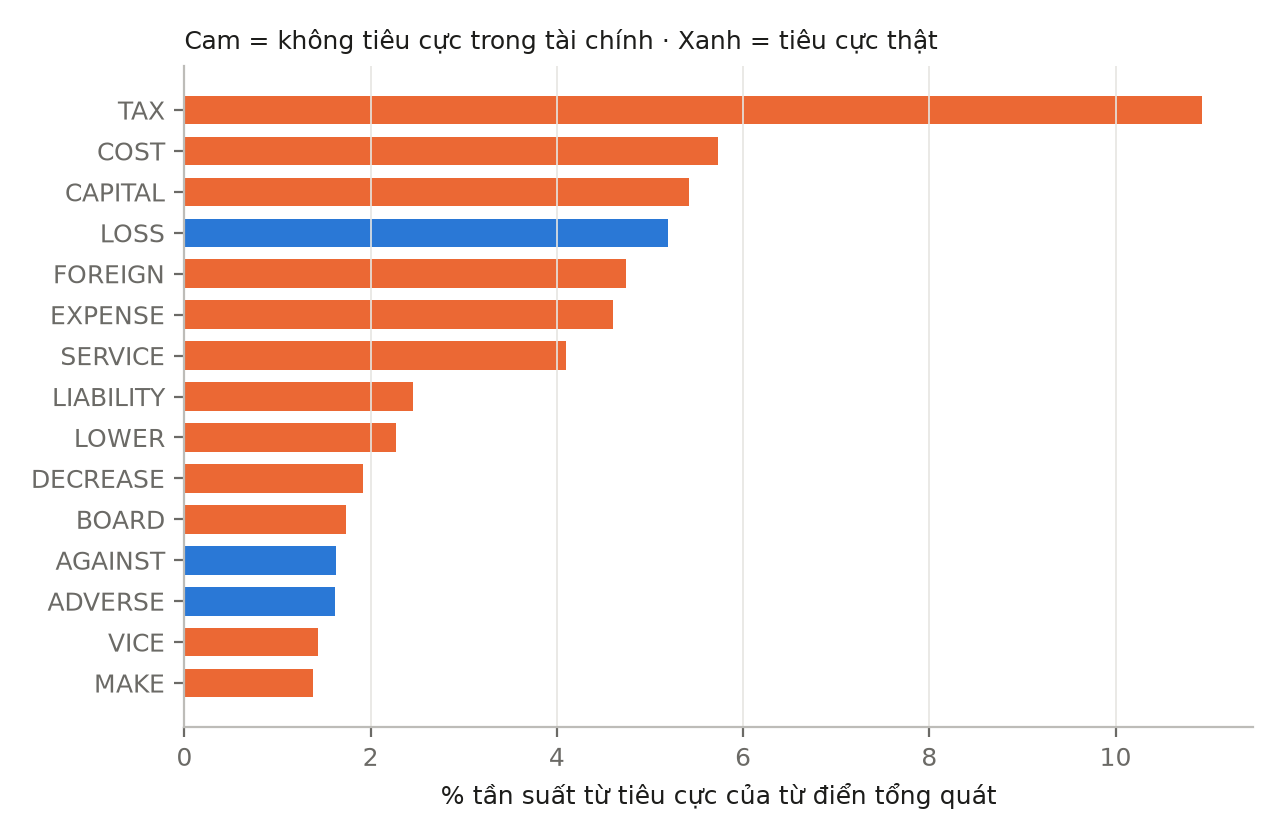

**Mục tiêu 3 – CAR có khác 0 không?**

,window,N,mean_pct,median_pct,t,p_t,p_wilcoxon,pct_positive,p_sign,t_BMP
0,"CAR[0,3]",500,-0.1703,-0.1267,-1.0225,0.3070,0.1880,48.2,0.4471,-0.9928
1,"CAR market-adjusted[0,3]",500,-0.0594,0.0069,-0.3501,0.7264,0.6935,50.2,0.9643,NaN
2,"CAR[0,1]",500,-0.1339,-0.1187,-0.9444,0.3454,0.0399,47.0,0.1946,-0.8339
3,"CAR market-adjusted[0,1]",500,-0.1008,-0.1064,-0.6988,0.4850,0.1413,48.2,0.4471,NaN
4,"CAR[-1,1]",500,0.0528,-0.0794,0.3344,0.7382,0.4362,47.4,0.2635,0.2484
5,"CAR market-adjusted[-1,1]",500,0.1588,0.0182,0.9865,0.3244,0.7495,50.4,0.8933,NaN
6,"CAR[0,5]",500,-0.2225,-0.0379,-1.1744,0.2408,0.3635,49.2,0.7543,-1.2637
7,"CAR market-adjusted[0,5]",500,-0.0519,0.0829,-0.2767,0.7821,0.8661,51.6,0.5024,NaN
8,"CAR[0,10]",500,-0.2310,-0.2210,-0.9953,0.3201,0.2879,47.0,0.1946,-1.4003
9,"CAR market-adjusted[0,10]",500,0.1770,0.1413,0.7430,0.4578,0.4393,51.8,0.4471,NaN


**CAR[0,3] theo nhóm giọng điệu**

,tone_grp,N,mean_pct,p_t
0,T1 Tiêu cực,167.0,-0.0567,0.8446
1,T2 Trung tính,166.0,-0.1492,0.5267
2,T3 Tích cực,167.0,-0.2627,0.1973
3,T3 − T1,334.0,-0.2059,0.5603


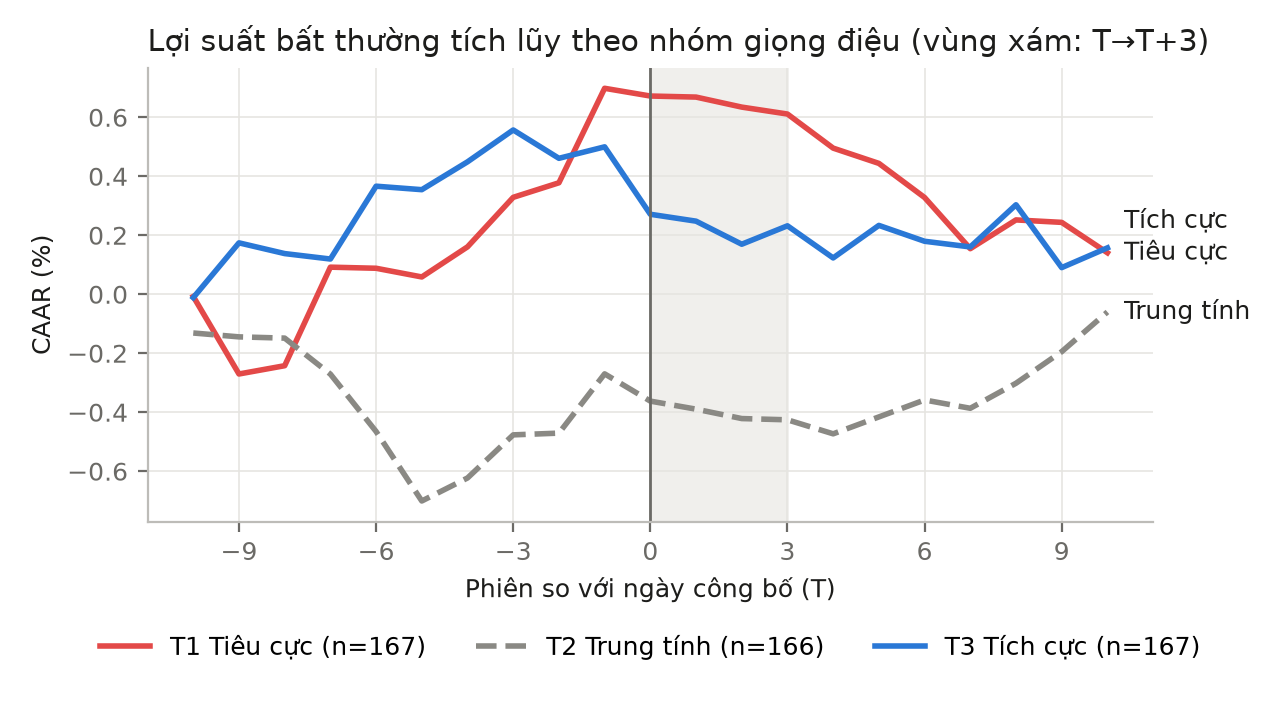

**regression_main**

,Unnamed: 0,M1 nền,M2 fin_neg,M3 gen_neg,M4 đối đầu,M5 net+unc,M6 tf-idf,M7 MD&A,M8 FinBERT
0,Intercept,0.0022 (0.0549),-0.0043 (0.0531),0.0313 (0.0550),0.0131 (0.0515),-0.0061 (0.0575),-0.0202 (0.0770),0.0382 (0.1118),-0.0072 (0.0561)
1,log_mcap,-0.0007 (0.0021),-0.0006 (0.0020),-0.0008 (0.0020),-0.0004 (0.0019),-0.0006 (0.0020),-0.0006 (0.0021),-0.0016 (0.0030),-0.0002 (0.0021)
2,log_bm,-0.0011 (0.0015),-0.0011 (0.0015),-0.0012 (0.0015),-0.0010 (0.0015),-0.0012 (0.0015),-0.0011 (0.0015),-0.0007 (0.0016),-0.0010 (0.0015)
3,log_turn,0.0070 (0.0052),0.0072 (0.0051),0.0071 (0.0050),0.0080 (0.0049),0.0072 (0.0057),0.0072 (0.0051),0.0078 (0.0057),0.0061 (0.0053)
4,pre_alpha,-6.3754* (3.2647),-6.4043** (3.2560),-6.5645** (3.2843),-6.7691** (3.2858),-6.4179** (3.2635),-6.4424** (3.2626),-6.5162* (3.5272),-6.2636* (3.2904)
5,log_len,0.0010 (0.0018),0.0014 (0.0024),-0.0014 (0.0022),-0.0005 (0.0024),0.0014 (0.0024),0.0028 (0.0060),0.0001 (0.0047),0.0009 (0.0018)
6,N,470,470,470,470,470,470,427,470
7,Adj. R2,0.0193,0.0172,0.0202,0.0197,0.0162,0.0173,0.0112,0.0188
8,fin_neg_z,NaN,-0.0005 (0.0016),NaN,-0.0024 (0.0019),NaN,NaN,NaN,NaN
9,gen_neg_z,NaN,NaN,0.0025* (0.0015),0.0035** (0.0016),NaN,NaN,NaN,NaN


**regression_fama_macbeth**

,Unnamed: 0,fin_neg_z,gen_neg_z,fin_neg_tfidf_z
0,Số kỳ cắt ngang,10,10,10
1,const,-0.0086 (t=-0.13),-0.0059 (t=-0.08),-0.0100 (t=-0.13)
2,fin_neg_tfidf_z,NaN,NaN,-0.0012 (t=-0.65)
3,fin_neg_z,-0.0011 (t=-0.98),NaN,NaN
4,gen_neg_z,NaN,-0.0004 (t=-0.27),NaN
5,log_bm,-0.0022* (t=-1.89),-0.0018 (t=-1.58),-0.0017* (t=-1.86)
6,log_len,0.0021 (t=1.13),0.0014 (t=0.57),0.0027 (t=1.02)
7,log_mcap,-0.0006 (t=-0.33),-0.0005 (t=-0.22),-0.0008 (t=-0.39)
8,log_turn,0.0009 (t=0.14),0.0009 (t=0.13),0.0003 (t=0.05)
9,pre_alpha,-6.6303** (t=-2.33),-5.9087** (t=-2.16),-6.4555** (t=-2.19)


**regression_robustness**

,Unnamed: 0,Market-adjusted,BHAR (LM 2011),Placebo −60 phiên,"CAR[0,1]","CAR[-1,1]","CAR[0,5]","CAR[0,10]"
0,Intercept,0.0025 (0.0605),0.0027 (0.0611),0.0116 (0.0401),-0.0186 (0.0611),-0.0048 (0.0719),0.0369 (0.0617),0.0118 (0.1178)
1,fin_neg_z,0.0005 (0.0018),0.0006 (0.0018),0.0008 (0.0012),0.0002 (0.0014),0.0024 (0.0018),-0.0005 (0.0018),-0.0019 (0.0025)
2,log_mcap,-0.0007 (0.0021),-0.0006 (0.0021),0.0001 (0.0014),0.0006 (0.0022),0.0013 (0.0028),-0.0029 (0.0023),-0.0026 (0.0043)
3,log_bm,-0.0007 (0.0014),-0.0008 (0.0014),0.0019 (0.0016),-0.0008 (0.0015),0.0002 (0.0018),-0.0031* (0.0019),-0.0046* (0.0025)
4,log_turn,0.0076 (0.0049),0.0083 (0.0050),0.0015 (0.0029),0.0037 (0.0052),0.0099 (0.0088),0.0030 (0.0055),0.0072 (0.0077)
5,pre_alpha,-1.5931 (3.3446),-1.7128 (3.4718),1.4697 (1.9674),-4.9476* (2.9040),-7.4419*** (2.8817),-10.1315*** (3.5632),-14.0999*** (4.2335)
6,log_len,0.0011 (0.0029),0.0010 (0.0028),-0.0013 (0.0017),-0.0000 (0.0017),-0.0021 (0.0022),0.0025 (0.0023),0.0035 (0.0033)
7,N,470,470,470,470,470,470,470
8,Adj. R2,-0.0032,-0.0015,0.0263,0.0200,0.0386,0.0307,0.0687


**assumption_tests**

,Unnamed: 0,0
0,Breusch-Pagan p,0.0000
1,Jarque-Bera p,0.0000
2,"corr(fin_neg, gen_neg)",0.5703
3,VIF fin_neg_z,2.8564
4,VIF log_mcap,2.8672
5,VIF log_bm,2.8814
6,VIF log_turn,2.9807
7,VIF pre_alpha,1.3553
8,VIF log_len,2.2688


In [3]:
m = 'us'
if m in MARKETS:
    out = ROOT / 'outputs' / m
    display(Markdown('**Mục tiêu 1 – thống kê tone**'), pd.read_csv(ROOT/'data'/m/'processed'/'tone_panel.csv').filter(regex='^(fin|gen)_').describe().T.round(4))
    display(Markdown('**Mục tiêu 2 – từ điển tổng quát gán sai**'), Markdown('```\n'+(out/'dictionary_comparison.txt').read_text(encoding='utf-8')+'\n```'))
    display(pd.read_csv(out/'misclassified_general_neg.csv').head(15), Image(str(out/'fig2_misclassified.png'), width=560))
    display(Markdown('**Mục tiêu 3 – CAR có khác 0 không?**'), pd.read_csv(out/'car_tests.csv'))
    display(Markdown('**CAR[0,3] theo nhóm giọng điệu**'), pd.read_csv(out/'car_by_tone.csv'), Image(str(out/'fig3_caar_by_tone.png'), width=560))
    for f in ['regression_main', 'regression_fama_macbeth', 'regression_robustness', 'assumption_tests']:
        display(Markdown(f'**{f}**'), pd.read_csv(out/f'{f}.csv'))


## Kết quả: Việt Nam – Thông điệp của ban lãnh đạo

**Mục tiêu 1 – thống kê tone**

,count,mean,std,min,25%,50%,75%,max
fin_neg,617.0,0.0053,0.0047,0.0000,0.0015,0.0042,0.0076,0.0210
fin_pos,617.0,0.0306,0.0110,0.0066,0.0232,0.0298,0.0371,0.0602
fin_unc,617.0,0.0026,0.0024,0.0000,0.0009,0.0021,0.0038,0.0109
fin_lit,617.0,0.0000,0.0001,0.0000,0.0000,0.0000,0.0000,0.0008
fin_net,617.0,0.7090,0.2453,0.0000,0.5652,0.7576,0.9111,1.0000
gen_neg,617.0,0.0202,0.0070,0.0056,0.0155,0.0199,0.0247,0.0384
gen_pos,617.0,0.0538,0.0126,0.0251,0.0454,0.0534,0.0620,0.0841
gen_unc,617.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
gen_lit,617.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
gen_net,617.0,0.4473,0.1768,0.0000,0.3333,0.4468,0.5663,0.8292


**Mục tiêu 2 – từ điển tổng quát gán sai**

```
Số văn bản: 617
Tỷ lệ 'nhiễu' của từ điển tổng quát (tần suất từ tiêu cực tổng quát không nằm trong danh sách tiêu cực tài chính): 92.8%

Tương quan:
         fin_neg  gen_neg  fin_net  gen_net
fin_neg    1.000    0.430   -0.885   -0.338
gen_neg    0.430    1.000   -0.383   -0.805
fin_net   -0.885   -0.383    1.000    0.408
gen_net   -0.338   -0.805    0.408    1.000

```

,word,freq,in_fin_negative,share_pct,nghia_trong_tai_chinh
0,cho,4458,False,26.34,NaN
1,thương,1538,False,9.09,NaN
2,bán,943,False,5.57,NaN
3,khó khăn,782,True,4.62,NaN
4,giảm,726,False,4.29,NaN
5,hạn,694,False,4.10,NaN
6,mạnh mẽ,694,False,4.10,NaN
7,xanh,454,False,2.68,NaN
8,thứ,408,False,2.41,NaN
9,ảnh hưởng,401,False,2.37,NaN


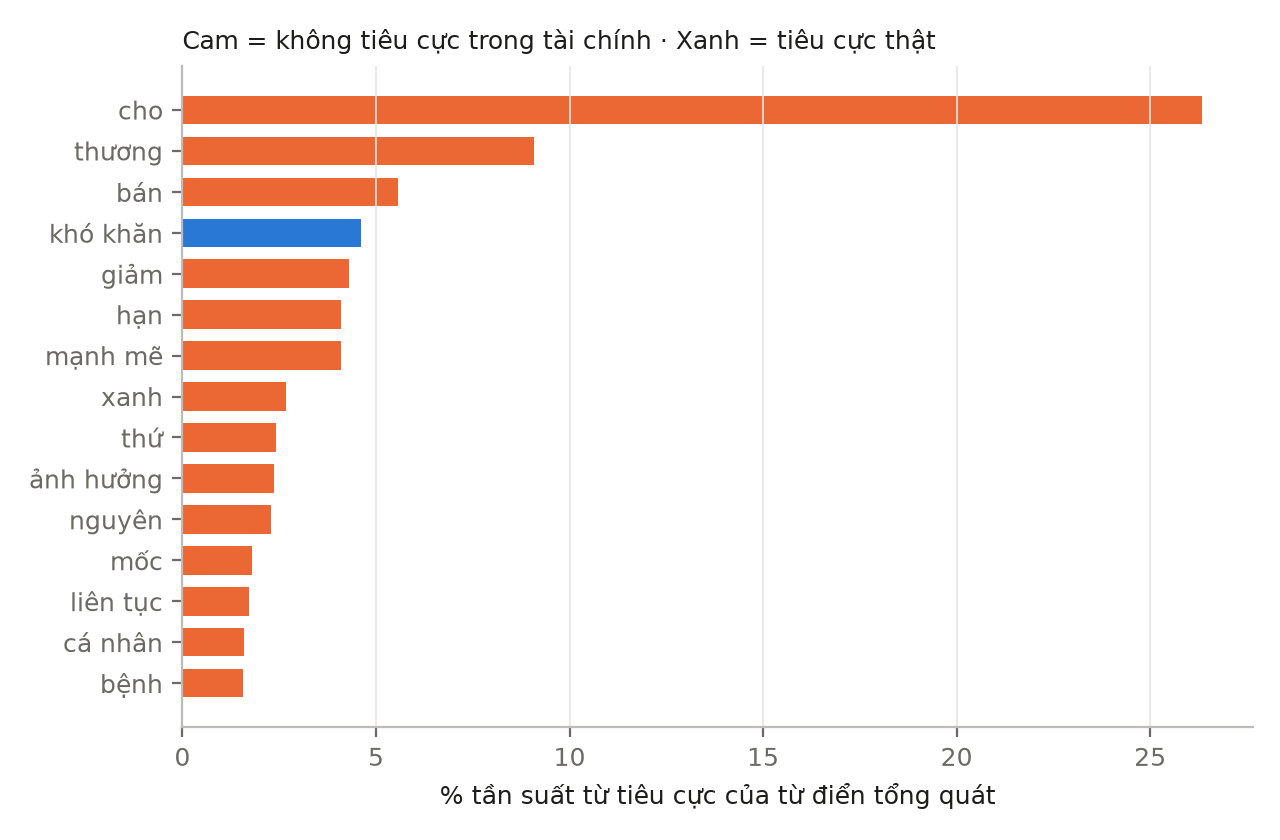

**Mục tiêu 3 – CAR có khác 0 không?**

,window,N,mean_pct,median_pct,t,p_t,p_wilcoxon,pct_positive,p_sign,t_BMP
0,"CAR[0,3]",514,-0.3036,-0.2423,-1.4184,0.1567,0.0876,46.4981,0.1226,-0.9931
1,"CAR market-adjusted[0,3]",514,-0.1267,-0.3428,-0.5954,0.5519,0.3094,46.6926,0.1454,NaN
2,"CAR[0,1]",516,-0.0638,-0.1911,-0.4430,0.6580,0.1282,45.5426,0.0475,-0.4256
3,"CAR market-adjusted[0,1]",516,0.0219,-0.2222,0.1564,0.8758,0.2775,45.7364,0.0583,NaN
4,"CAR[-1,1]",514,-0.0391,-0.1972,-0.2272,0.8203,0.4043,46.3035,0.1026,-0.2393
5,"CAR market-adjusted[-1,1]",514,0.0448,-0.0748,0.2752,0.7833,0.7480,48.2490,0.4534,NaN
6,"CAR[0,5]",514,-0.7016,-0.6974,-2.7382,0.0064,0.0012,44.5525,0.0152,-2.0732
7,"CAR market-adjusted[0,5]",514,-0.5182,-0.5401,-2.0102,0.0449,0.0124,45.1362,0.0306,NaN
8,"CAR[0,10]",512,-0.9816,-1.0462,-2.8465,0.0046,0.0009,43.5547,0.0040,-2.1991
9,"CAR market-adjusted[0,10]",512,-0.5967,-0.6809,-1.7435,0.0818,0.0149,45.3125,0.0377,NaN


**CAR[0,3] theo nhóm giọng điệu**

,tone_grp,N,mean_pct,p_t
0,T1 Tiêu cực,171.0,-0.7396,0.0566
1,T2 Trung tính,172.0,-0.1695,0.5860
2,T3 Tích cực,171.0,-0.0382,0.9110
3,T3 − T1,342.0,0.7014,0.1739


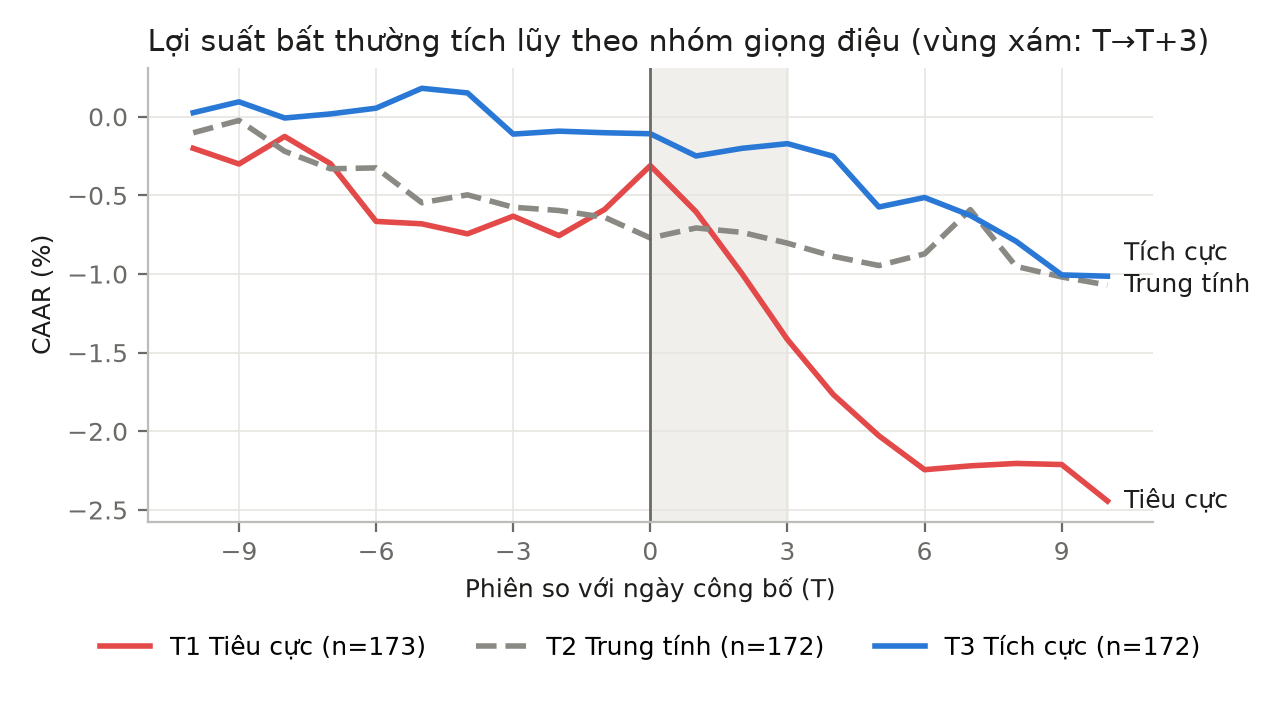

**regression_main**

,Unnamed: 0,M1 nền,M2 fin_neg,M3 gen_neg,M4 đối đầu,M5 net+unc,M6 tf-idf
0,Intercept,0.0699 (0.0509),0.0739 (0.0506),0.0679 (0.0504),0.0739 (0.0499),0.0703 (0.0501),0.0627 (0.0495)
1,log_tradeval,-0.0043* (0.0024),-0.0044* (0.0024),-0.0043* (0.0024),-0.0044* (0.0024),-0.0044* (0.0024),-0.0044* (0.0024)
2,pre_ret,-0.0308 (0.0206),-0.0320 (0.0205),-0.0310 (0.0206),-0.0320 (0.0205),-0.0325 (0.0205),-0.0321 (0.0203)
3,log_len,0.0000 (0.0040),-0.0003 (0.0040),0.0003 (0.0041),-0.0003 (0.0040),0.0001 (0.0039),0.0013 (0.0042)
4,vn30,0.0020 (0.0056),0.0019 (0.0055),0.0023 (0.0056),0.0019 (0.0056),0.0010 (0.0056),0.0018 (0.0054)
5,beta,0.0024 (0.0064),0.0028 (0.0064),0.0026 (0.0065),0.0028 (0.0065),0.0035 (0.0064),0.0025 (0.0064)
6,N,514,514,514,514,514,514
7,Adj. R2,0.0105,0.0108,0.0090,0.0088,0.0153,0.0097
8,fin_neg_z,NaN,-0.0024 (0.0020),NaN,-0.0024 (0.0023),NaN,NaN
9,gen_neg_z,NaN,NaN,-0.0010 (0.0021),-0.0000 (0.0024),NaN,NaN


**regression_fama_macbeth**

,Unnamed: 0,fin_neg_z,gen_neg_z,fin_neg_tfidf_z
0,Số kỳ cắt ngang,10,10,10
1,beta,-0.0009 (t=-0.10),-0.0004 (t=-0.04),-0.0011 (t=-0.13)
2,const,0.0896 (t=1.33),0.0735 (t=1.13),0.0764 (t=1.18)
3,fin_neg_tfidf_z,NaN,NaN,-0.0007 (t=-0.36)
4,fin_neg_z,-0.0009 (t=-0.43),NaN,NaN
5,gen_neg_z,NaN,-0.0010 (t=-0.97),NaN
6,log_len,-0.0035 (t=-0.99),-0.0023 (t=-0.62),-0.0017 (t=-0.47)
7,log_tradeval,-0.0038 (t=-1.23),-0.0034 (t=-1.14),-0.0037 (t=-1.19)
8,pre_ret,-0.0711*** (t=-3.14),-0.0695*** (t=-3.04),-0.0655*** (t=-3.14)
9,vn30,-0.0036 (t=-0.59),-0.0032 (t=-0.57),-0.0038 (t=-0.63)


**regression_robustness**

,Unnamed: 0,Market-adjusted,BHAR (LM 2011),Placebo −60 phiên,"CAR[0,1]","CAR[-1,1]","CAR[0,5]","CAR[0,10]"
0,Intercept,0.0787 (0.0516),0.0819 (0.0523),-0.0276 (0.0260),0.0423 (0.0315),0.0251 (0.0384),0.1342** (0.0641),0.1817** (0.0840)
1,fin_neg_z,-0.0017 (0.0020),-0.0020 (0.0020),0.0025 (0.0016),0.0008 (0.0013),0.0014 (0.0016),-0.0063*** (0.0023),-0.0049 (0.0031)
2,log_tradeval,-0.0043* (0.0025),-0.0045* (0.0025),0.0034** (0.0015),-0.0032** (0.0016),-0.0023 (0.0018),-0.0069** (0.0028),-0.0108*** (0.0040)
3,pre_ret,-0.0063 (0.0214),-0.0076 (0.0207),0.0361** (0.0182),-0.0073 (0.0171),-0.0013 (0.0183),-0.0607** (0.0266),-0.0640* (0.0379)
4,log_len,0.0004 (0.0041),0.0002 (0.0041),0.0010 (0.0025),0.0017 (0.0027),0.0023 (0.0035),-0.0035 (0.0057),0.0002 (0.0074)
5,vn30,0.0014 (0.0054),0.0015 (0.0054),-0.0007 (0.0037),0.0012 (0.0038),-0.0028 (0.0042),0.0054 (0.0071),0.0107 (0.0089)
6,beta,-0.0059 (0.0066),-0.0056 (0.0066),-0.0181*** (0.0042),0.0032 (0.0045),0.0049 (0.0048),0.0053 (0.0069),-0.0002 (0.0096)
7,N,514,517,499,516,514,514,512
8,Adj. R2,0.0221,0.0244,0.0544,0.0066,0.0046,0.0371,0.0565


**assumption_tests**

,Unnamed: 0,0
0,Breusch-Pagan p,0.0009
1,Jarque-Bera p,0.0000
2,"corr(fin_neg, gen_neg)",0.4425
3,VIF fin_neg_z,1.2505
4,VIF log_tradeval,2.9265
5,VIF pre_ret,1.0445
6,VIF log_len,1.1135
7,VIF vn30,1.3152
8,VIF beta,1.4609


In [4]:
m = 'vn'
if m in MARKETS:
    out = ROOT / 'outputs' / m
    display(Markdown('**Mục tiêu 1 – thống kê tone**'), pd.read_csv(ROOT/'data'/m/'processed'/'tone_panel.csv').filter(regex='^(fin|gen)_').describe().T.round(4))
    display(Markdown('**Mục tiêu 2 – từ điển tổng quát gán sai**'), Markdown('```\n'+(out/'dictionary_comparison.txt').read_text(encoding='utf-8')+'\n```'))
    display(pd.read_csv(out/'misclassified_general_neg.csv').head(15), Image(str(out/'fig2_misclassified.png'), width=560))
    display(Markdown('**Mục tiêu 3 – CAR có khác 0 không?**'), pd.read_csv(out/'car_tests.csv'))
    display(Markdown('**CAR[0,3] theo nhóm giọng điệu**'), pd.read_csv(out/'car_by_tone.csv'), Image(str(out/'fig3_caar_by_tone.png'), width=560))
    for f in ['regression_main', 'regression_fama_macbeth', 'regression_robustness', 'assumption_tests']:
        display(Markdown(f'**{f}**'), pd.read_csv(out/f'{f}.csv'))


## Diễn giải nhanh
- **T3 − T1 dương, có ý nghĩa** và hệ số `fin_neg_z` âm → giọng điệu mang thông tin.
- **M4 đối đầu**: nếu `fin_neg_z` giữ ý nghĩa còn `gen_neg_z` mất → từ điển tài chính vượt trội (Mục tiêu 2).
- **Placebo** không có ý nghĩa → kết quả không phải do ngẫu nhiên/xu hướng chung.

Kết quả thực tế của lần chạy này và cách diễn giải: xem `RESULTS.md`.